# Harris Corner Detection
Today we are going to be implementing the Harris Corner Detection algorithm!!! 
It is important to note that knowing how to do the code for the first couple cells is not very important since these are just 
basic visualizations used in my blog. 
    
Most of these were generated using AI so I think its more important to know what you want to code and how to prompt in a way to get that. 
The code for the actual algorithm however I think is very critical to understand if you want to know how this algorithm works on a fundamental level. 
    I would not skimp out on neither the math nor the code (In the notebook there will be a clear sign when we are shifting into relevent code).


www.aryanjain.work/blog/harris-corner-detection

# Looking at and Exploring the Data 
It is not required to understand this code, simply look at blog for plots unless you are interested in it

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

(384, 512, 3)


Text(0.5, 1.0, 'Home')

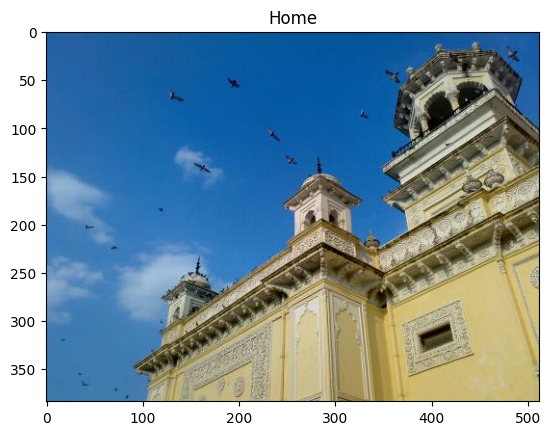

In [3]:
color_img = cv2.imread("../data/harris-corner-detection/home.jpg")
color_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
print(color_img.shape)
plt.imshow(color_img)
plt.title("Home")

In [4]:
def visualize_regions(
    img,
    patch_coords,
    edge_coords,
    corner_coords,
    output_path,
    shift=(0, 0), # (dy, dx)
    titles=("Flat Patch", "Edge Region", "Corner Region")
):
    """
    img: input image (grayscale or color)
    coords: (y1, y2, x1, x2)
    shift: (dy, dx) to move boxes
    """

    # ---- helper ----
    def shift_coords(coords, dy, dx):
        y1, y2, x1, x2 = coords
        return (y1 + dy, y2 + dy, x1 + dx, x2 + dx)

    def draw_box(im, coords, color, thickness=2):
        y1, y2, x1, x2 = coords
        cv2.rectangle(im, (x1, y1), (x2 - 1, y2 - 1), color, thickness)

    # ---- apply shift ----
    dy, dx = shift
    patch_coords = shift_coords(patch_coords, dy, dx)
    edge_coords = shift_coords(edge_coords, dy, dx)
    corner_coords = shift_coords(corner_coords, dy, dx)

    # ---- ensure color image for drawing ----
    if len(img.shape) == 2:  # grayscale
        img_boxes = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_boxes = img.copy()

    # ---- extract patches (use original image, not boxed one) ----
    def crop(im, coords):
        y1, y2, x1, x2 = coords
        return im[y1:y2, x1:x2]

    patch = crop(img, patch_coords)
    edge = crop(img, edge_coords)
    corner = crop(img, corner_coords)

    # ---- draw boxes ----
    draw_box(img_boxes, patch_coords, (255, 0, 0))   # red (matplotlib RGB)
    draw_box(img_boxes, edge_coords, (0, 255, 0))    # green
    draw_box(img_boxes, corner_coords, (0, 0, 255))  # blue

    # ---- plotting ----
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img_boxes)
    plt.title("Original Image")
    plt.axis("off")

    # handle grayscale vs color patches
    def show_patch(p, title):
        plt.imshow(p, cmap="gray" if len(p.shape) == 2 else None)
        plt.title(title)
        plt.axis("off")

    plt.subplot(1, 4, 2)
    show_patch(patch, titles[0])

    plt.subplot(1, 4, 3)
    show_patch(edge, titles[1])

    plt.subplot(1, 4, 4)
    show_patch(corner, titles[2])

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

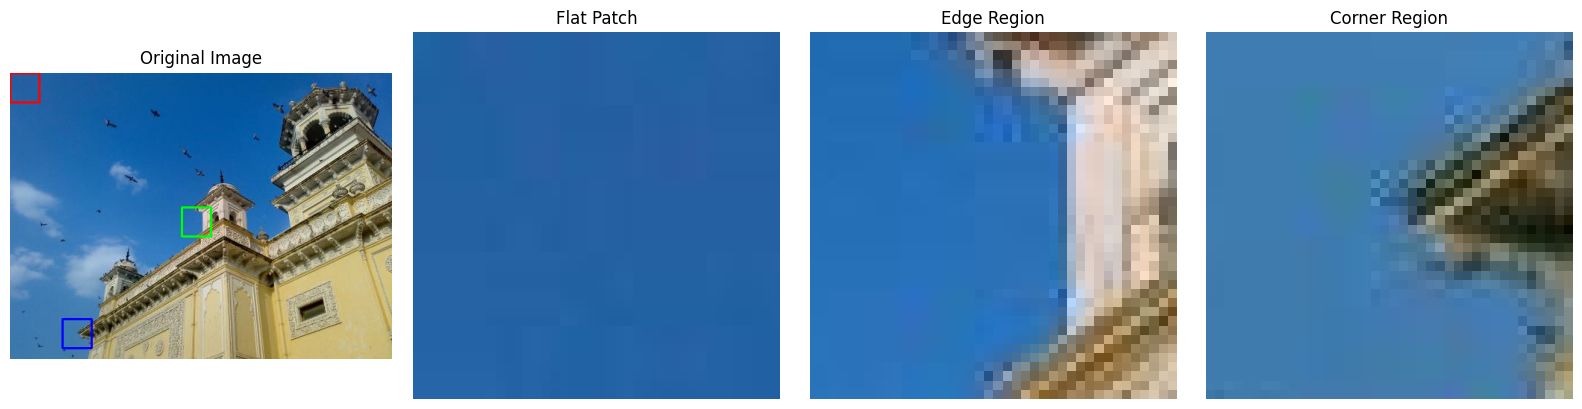

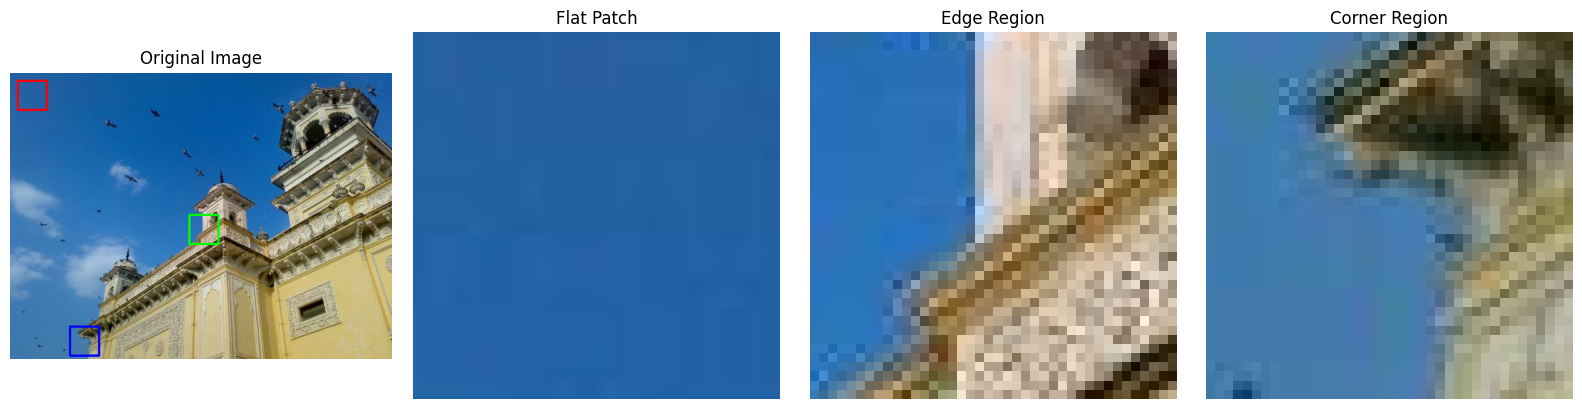

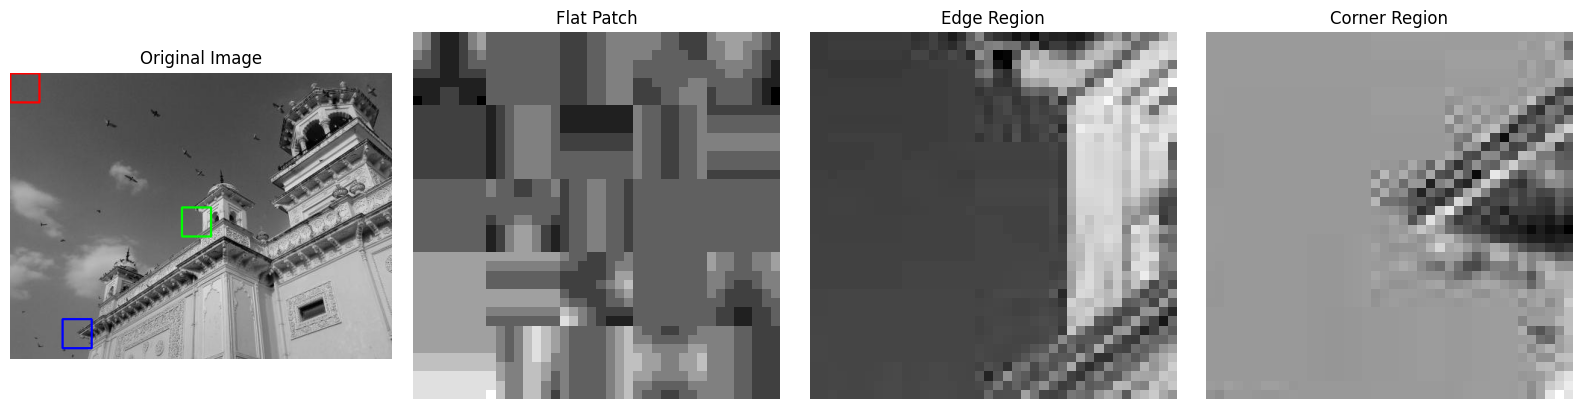

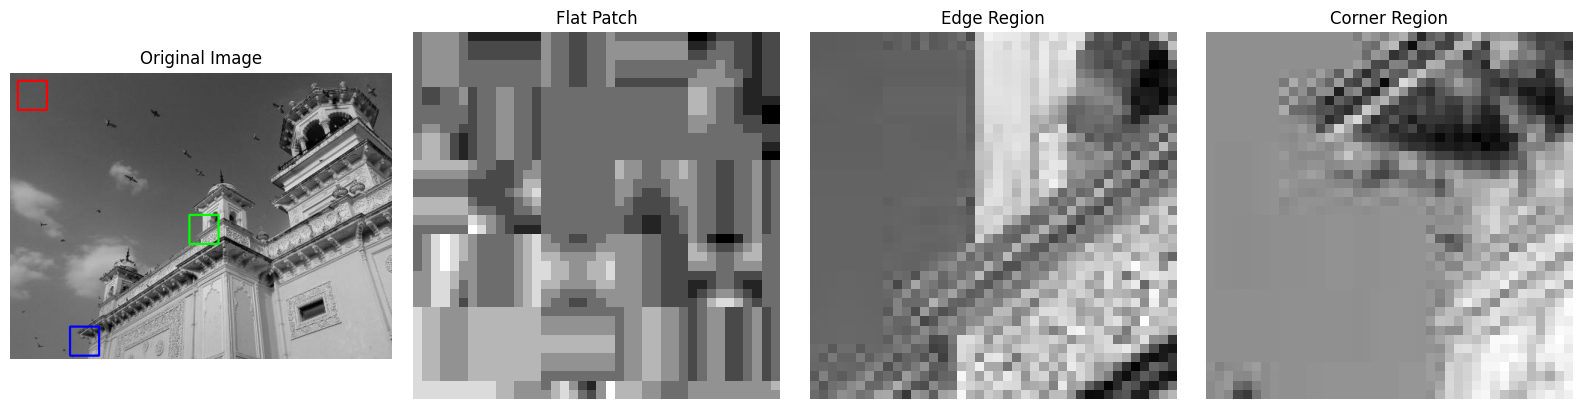

In [5]:
patch_coords = (0, 40, 0, 40)
edge_coords = (180, 220, 230, 270)
corner_coords = (330, 370, 70, 110)

visualize_regions(
    img=color_img,
    patch_coords=patch_coords,
    edge_coords=edge_coords,
    corner_coords=corner_coords,
    output_path="../outputs/harris-corner-detection/color_patch_edge_corner.png"
)

visualize_regions(
    img=color_img,
    patch_coords=patch_coords,
    edge_coords=edge_coords,
    corner_coords=corner_coords,
    shift = (10,10),
    output_path="../outputs/harris-corner-detection/color_shifted_patch_edge_corner.png"
)

# VIEW THE SAME THINGS IN GRAY SCALE

gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)

visualize_regions(
    img=gray_img,
    patch_coords=patch_coords,
    edge_coords=edge_coords,
    corner_coords=corner_coords,
    output_path="../outputs/harris-corner-detection/gray_patch_edge_corner.png"
)

visualize_regions(
    img=gray_img,
    patch_coords=patch_coords,
    edge_coords=edge_coords,
    corner_coords=corner_coords,
    shift = (10,10),
    output_path="../outputs/harris-corner-detection/gray_shifted_patch_edge_corner.png"
)

In [17]:
# AUTO-CORRELATION FUNCTION
def compute_autocorrelation_surface(patch, max_shift=10, use_gaussian=True):
    """
    Compute the shifted-window error surface E(u, v) for a grayscale patch.

    Parameters
    ----------
    patch : np.ndarray
        2D grayscale patch
    max_shift : int
        Computes E(u,v) for u,v in [-max_shift, max_shift]
    use_gaussian : bool
        Whether to apply a Gaussian weighting window

    Returns
    -------
    E : np.ndarray
        2D array of shape (2*max_shift+1, 2*max_shift+1)
        where E[v_index, u_index] corresponds to shift (u, v)
    shifts : np.ndarray
        Array of shift values from -max_shift to max_shift
    """
    patch = patch.astype(np.float64)

    h, w = patch.shape
    shifts = np.arange(-max_shift, max_shift + 1)
    E = np.zeros((len(shifts), len(shifts)), dtype=np.float64)

    # Optional weighting window
    if use_gaussian:
        gx = cv2.getGaussianKernel(w, 0)
        gy = cv2.getGaussianKernel(h, 0)
        window = gy @ gx.T
    else:
        window = np.ones((h, w), dtype=np.float64)

    for vi, v in enumerate(shifts):
        for ui, u in enumerate(shifts):
            # overlap coordinates in original patch
            x1_src = max(0, -u)
            x2_src = min(w, w - u)
            y1_src = max(0, -v)
            y2_src = min(h, h - v)

            x1_shift = x1_src + u
            x2_shift = x2_src + u
            y1_shift = y1_src + v
            y2_shift = y2_src + v

            if x1_src >= x2_src or y1_src >= y2_src:
                E[vi, ui] = np.nan
                continue

            original = patch[y1_src:y2_src, x1_src:x2_src]
            shifted = patch[y1_shift:y2_shift, x1_shift:x2_shift]
            weights = window[y1_src:y2_src, x1_src:x2_src]

            diff = shifted - original
            E[vi, ui] = np.sum(weights * diff * diff)

    return E, shifts

In [18]:
def plot_three_autocorrelations(E_patch, E_edge, E_corner, shifts, save_path=None):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(
        E_patch,
        extent=[shifts[0], shifts[-1], shifts[-1], shifts[0]],
        cmap="viridis"
    )
    plt.title("Flat Patch")
    plt.xlabel("u")
    plt.ylabel("v")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(
        E_edge,
        extent=[shifts[0], shifts[-1], shifts[-1], shifts[0]],
        cmap="viridis"
    )
    plt.title("Edge")
    plt.xlabel("u")
    plt.ylabel("v")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(
        E_corner,
        extent=[shifts[0], shifts[-1], shifts[-1], shifts[0]],
        cmap="viridis"
    )
    plt.title("Corner")
    plt.xlabel("u")
    plt.ylabel("v")
    plt.colorbar()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

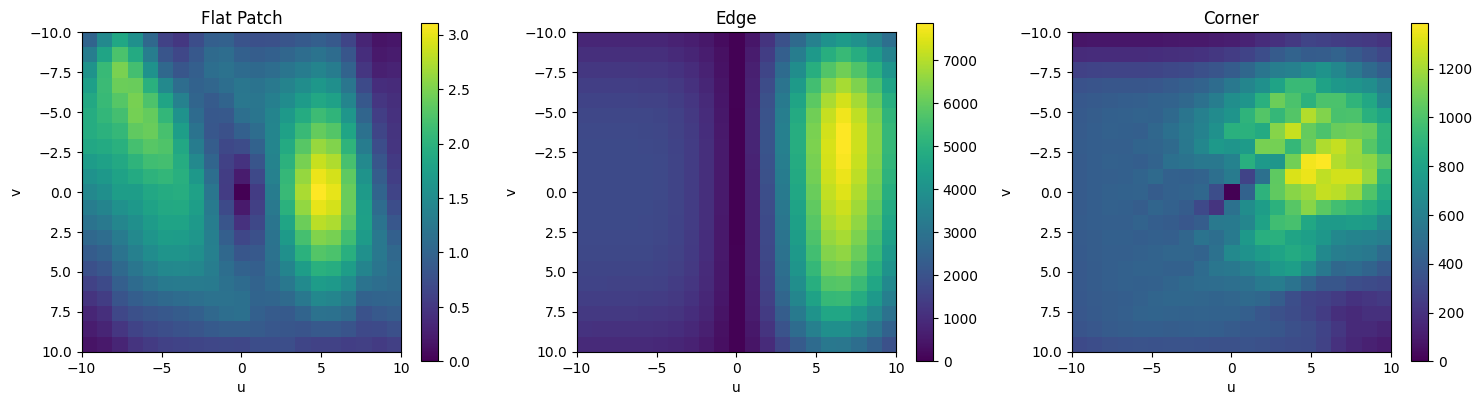

In [19]:
def crop_region(img, coords):
    y1, y2, x1, x2 = coords
    return img[y1:y2, x1:x2]

patch_coords = (0, 20, 0, 20)
edge_coords = (190, 210, 245, 265)
corner_coords = (340, 360, 80, 100)

patch = crop_region(gray_img, patch_coords)
edge = crop_region(gray_img, edge_coords)
corner = crop_region(gray_img, corner_coords)

E_patch, shifts = compute_autocorrelation_surface(patch, max_shift=10)
E_edge, shifts = compute_autocorrelation_surface(edge, max_shift=10)
E_corner, shifts = compute_autocorrelation_surface(corner, max_shift=10)

plot_three_autocorrelations(
    E_patch, E_edge, E_corner, shifts,
    save_path="../outputs/harris-corner-detection/autocorrelation_surfaces.png"
)